In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/aac_shelter_outcomes.csv')

print(df.shape)
print(df.dtypes)
df.head()

In [2]:
print(df['outcome_type'].value_counts())
print(f"\nMissing values:\n{df.isnull().sum()}")

outcome_type
Adoption           33112
Transfer           23499
Return to Owner    14354
Euthanasia          6080
Died                 680
Disposal             307
Rto-Adopt            150
Missing               46
Relocate              16
Name: count, dtype: int64

Missing values:
age_upon_outcome        8
animal_id               0
animal_type             0
breed                   0
color                   0
date_of_birth           0
datetime                0
monthyear               0
name                23886
outcome_subtype     42293
outcome_type           12
sex_upon_outcome        2
dtype: int64


In [3]:
keep = ['Adoption', 'Transfer', 'Euthanasia']
df_clean = df[df['outcome_type'].isin(keep)].copy()

df_clean['has_name'] = df_clean['name'].notna().astype(int)

df_clean = df_clean.drop(columns=['animal_id', 'name', 'outcome_subtype', 'monthyear', 'date_of_birth'])

print(df_clean['outcome_type'].value_counts())
print(df_clean.shape)

outcome_type
Adoption      33112
Transfer      23499
Euthanasia     6080
Name: count, dtype: int64
(62691, 8)


In [4]:
def parse_age(age_str):
    if pd.isna(age_str):
        return None
    parts = age_str.split()
    value = int(parts[0])
    unit = parts[1]
    if 'year' in unit:
        return value * 365
    elif 'month' in unit:
        return value * 30
    elif 'week' in unit:
        return value * 7
    elif 'day' in unit:
        return value
    return None

df_clean['age_days'] = df_clean['age_upon_outcome'].apply(parse_age)
df_clean['is_mix'] = df_clean['breed'].str.contains('Mix', case=False).astype(int)
df_clean['is_neutered'] = df_clean['sex_upon_outcome'].str.contains('Neutered|Spayed', case=False).astype(int)
df_clean['is_intact'] = df_clean['sex_upon_outcome'].str.contains('Intact', case=False).astype(int)

df_clean['datetime'] = pd.to_datetime(df_clean['datetime'])
df_clean['month'] = df_clean['datetime'].dt.month
df_clean['day_of_week'] = df_clean['datetime'].dt.dayofweek

print(df_clean[['age_days', 'is_mix', 'is_neutered', 'is_intact', 'month', 'day_of_week']].head())
print(df_clean['age_days'].isna().sum())

   age_days  is_mix  is_neutered  is_intact  month  day_of_week
0      14.0       1            0          1      7            1
1     365.0       1            1          0     11            3
2     365.0       0            1          0      6            1
3    3285.0       1            1          0      6            6
4     150.0       1            0          0      7            0
6


In [5]:
df_model = df_clean.dropna(subset=['age_days'])

features = ['age_days', 'is_mix', 'is_neutered', 'is_intact', 'has_name', 'month', 'day_of_week']
X = pd.get_dummies(df_model[features + ['animal_type', 'color']], columns=['animal_type', 'color'])
y = df_model['outcome_type']

print(X.shape)
print(y.value_counts())

(62685, 504)
outcome_type
Adoption      33112
Transfer      23497
Euthanasia     6076
Name: count, dtype: int64


In [6]:
X = pd.get_dummies(df_model[features + ['animal_type']], columns=['animal_type'])

print(X.shape)
print(X.columns.tolist())

(62685, 12)
['age_days', 'is_mix', 'is_neutered', 'is_intact', 'has_name', 'month', 'day_of_week', 'animal_type_Bird', 'animal_type_Cat', 'animal_type_Dog', 'animal_type_Livestock', 'animal_type_Other']


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Adoption       0.81      0.89      0.84      6622
  Euthanasia       0.74      0.58      0.65      1215
    Transfer       0.75      0.69      0.72      4700

    accuracy                           0.78     12537
   macro avg       0.77      0.72      0.74     12537
weighted avg       0.78      0.78      0.78     12537



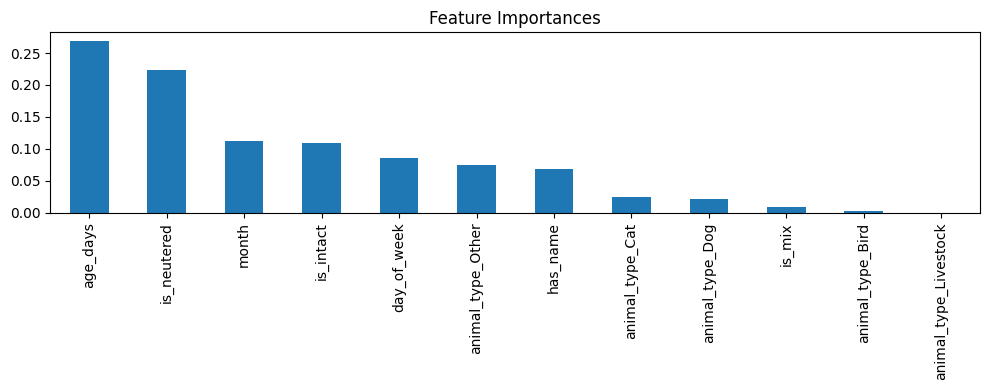

In [8]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 4), title='Feature Importances')
plt.tight_layout()
plt.show()

In [9]:
model_balanced = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

    Adoption       0.82      0.85      0.83      6622
  Euthanasia       0.57      0.63      0.60      1215
    Transfer       0.73      0.67      0.70      4700

    accuracy                           0.76     12537
   macro avg       0.71      0.72      0.71     12537
weighted avg       0.76      0.76      0.76     12537



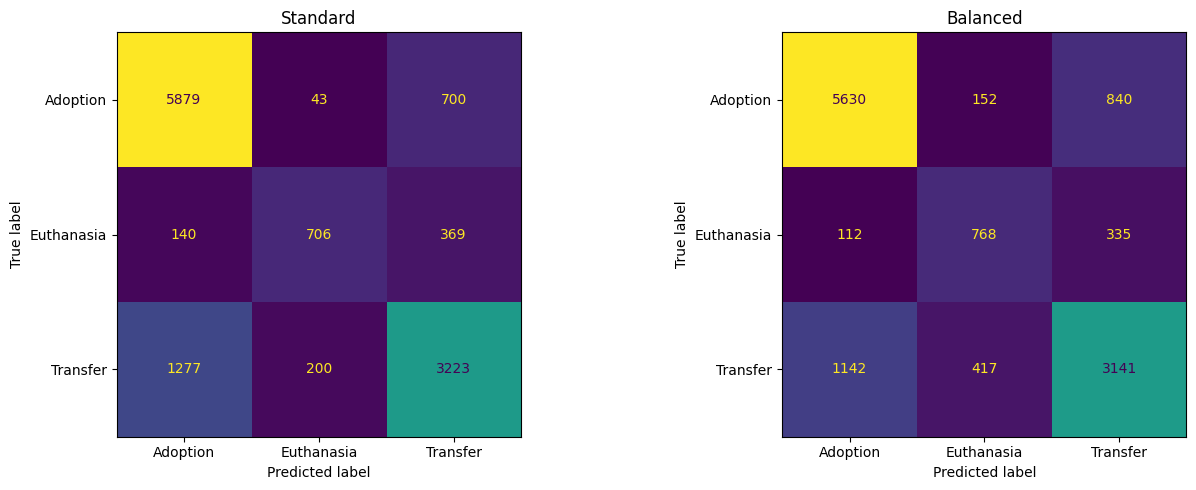

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], colorbar=False)
axes[0].set_title('Standard')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_balanced, ax=axes[1], colorbar=False)
axes[1].set_title('Balanced')

plt.tight_layout()
plt.show()

In [11]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(model_balanced, '../models/shelter_model.pkl')
joblib.dump(X.columns.tolist(), '../models/feature_columns.pkl')
print("Saved.")

Saved.
